<a href="https://colab.research.google.com/github/EdvanylsonAssuncao/curso_IA_generativa/blob/main/yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.4 MB/s eta 0:00:00


[SISTEMA] Carregar a Rede Neural (YOLOv8) ...

--- OBJETOS DETECTADOS NO BANDO DE DADOS DA IA ---
 -> Detecção: CAR | Confiança: 92.9%
 -> Detecção: PERSON | Confiança: 86.6%
 -> Detecção: PERSON | Confiança: 86.6%
 -> Detecção: PERSON | Confiança: 85.9%
 -> Detecção: CAR | Confiança: 84.6%
 -> Detecção: CAR | Confiança: 79.4%
 -> Detecção: CAR | Confiança: 74.4%
 -> Detecção: BUS | Confiança: 62.8%
 -> Detecção: CAR | Confiança: 61.8%
 -> Detecção: CAR | Confiança: 42.0%
 -> Detecção: MOTORCYCLE | Confiança: 36.6%
 -> Detecção: TRAFFIC LIGHT | Confiança: 28.7%
 -> Detecção: CAR | Confiança: 27.0%
 -> Detecção: CAR | Confiança: 26.6%

 Resultado do Monitoramento por IA ---


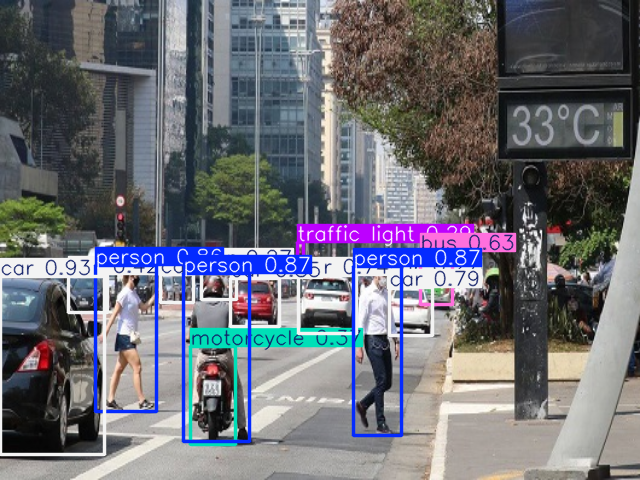

In [7]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1. Carregar o modelo YOLOv8 pré-treinando
print("[SISTEMA] Carregar a Rede Neural (YOLOv8) ...")
modelo_yolo = YOLO('yolov8n.pt')

# 2. Ler a imagem estática
imagem_bruta = cv2.imread('imagem.jpg')

# 3. Redimensionar para um tamanho padrão
imagem_redimensionada = cv2.resize(imagem_bruta, (640, 480))

# 4. Passar a imagem tratada na iteligência no YOLOv8
# e gerar o mapa visual com as Bounding Boxes (caixas delimitadoras)
resultados = modelo_yolo(imagem_redimensionada, verbose=False)

# 5. Desenhar os retângulos e escrever o nome das classes
imagem_final_ia = resultados[0].plot()

# 6. Imprimir os objetos detectados
print("\n--- OBJETOS DETECTADOS NO BANDO DE DADOS DA IA ---")
for caixa in resultados[0].boxes:
    classe_id = int(caixa.cls[0])
    nome_objeto = modelo_yolo.names[classe_id]

    # Extrair o score de confiança
    confianca = float(caixa.conf[0]) * 100

    print(f" -> Detecção: {nome_objeto.upper()} | Confiança: {confianca:.1f}%")

# 7. Exibir o painel visual para validação
print("\n Resultado do Monitoramento por IA ---")
cv2_imshow(imagem_final_ia)
